<a href="https://colab.research.google.com/github/koushik1904/ML_assignments/blob/main/ML_assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/CO2 Emissions_Canada.csv")

# Select feature and target
X = df[['Engine Size(L)']].values
y = df['CO2 Emissions(g/km)'].values

In [3]:
model = LinearRegression()
model.fit(X, y)

beta_original = model.coef_[0]
print("Original β₁ (Engine Size coefficient):", beta_original)

Original β₁ (Engine Size coefficient): 36.77731518641943


In [4]:
B = 2000
boot_coefs = []

for i in range(B):
    X_sample, y_sample = resample(X, y)

    model_boot = LinearRegression()
    model_boot.fit(X_sample, y_sample)

    boot_coefs.append(model_boot.coef_[0])

boot_coefs = np.array(boot_coefs)

In [5]:
ci_90 = np.percentile(boot_coefs, [5, 95])
print("90% CI:", ci_90)

90% CI: [36.26244914 37.25361662]


In [6]:
ci_95 = np.percentile(boot_coefs, [2.5, 97.5])
print("95% CI:", ci_95)

95% CI: [36.16799339 37.35391817]


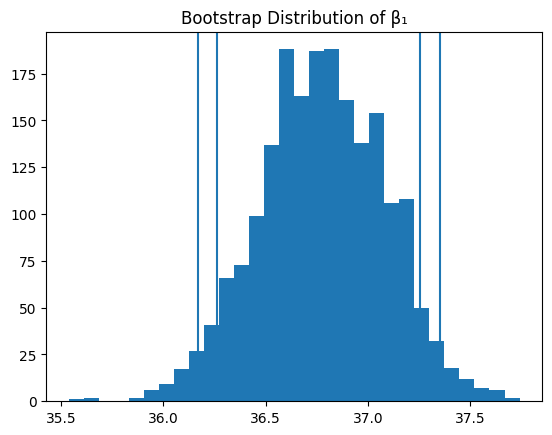

In [7]:
plt.hist(boot_coefs, bins=30)
plt.axvline(ci_90[0])
plt.axvline(ci_90[1])
plt.axvline(ci_95[0])
plt.axvline(ci_95[1])
plt.title("Bootstrap Distribution of β₁")
plt.show()